# CPS 3840 Final Project: Human Activity Recognition from Smartphone Sensor Data

**Team Members:** Alisha Patel, Wenwen Lei, Chenyu Xie

**Date:** April 9th 2026  

**Course:** CPS 3840 – Deep Learning and Applications on Real-World Data

---

## Project Overview

This project focuses on **Human Activity Recognition (HAR)** using smartphone sensor data from the UCI HAR dataset. We build and compare deep learning models that classify physical activities (**Walking, Walking Upstairs, Walking Downstairs, Sitting, Standing, Laying**) based on 561 engineered features from smartphone accelerometers and gyroscopes.

**Dataset:** UCI Human Activity Recognition Using Smartphones  
**Source:** https://archive.ics.uci.edu/dataset/240/human+activity+recognition+using+smartphones

In [1]:
#Libraries Imported
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv1D, MaxPooling1D, Flatten, LSTM, Reshape
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
import numpy as np
import tensorflow as tf
import random

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

## 1. Introduction

Human Activity Recognition (HAR) is an important machine learning application that helps identify human physical activities using sensor data. HAR is widely used in healthcare, fitness tracking, smart homes, and mobile applications.

In this project, we use the **UCI HAR dataset**, which contains smartphone sensor measurements collected from accelerometers and gyroscopes. The goal is to classify a person's activity into one of six categories:

- Walking
- Walking Upstairs
- Walking Downstairs
- Sitting
- Standing
- Laying

We compare multiple deep learning models to determine which approach performs best for this classification task.

## 2. Dataset Description

The dataset used in this project is the **UCI Human Activity Recognition Using Smartphones Dataset**.

### Dataset facts:
- **Total instances:** 10,299
- **Training samples:** 7,352
- **Testing samples:** 2,947
- **Features:** 561
- **Classes:** 6 human activities

### Activities:
1. Walking
2. Walking Upstairs
3. Walking Downstairs
4. Sitting
5. Standing
6. Laying

The 561 features were engineered from raw accelerometer and gyroscope signals collected from smartphones worn by participants.

In [7]:
import zipfile
import os
from google.colab import files

print("Please upload the 'UCI HAR Dataset.zip' file:")
uploaded = files.upload()

if uploaded:
    outer_zip = list(uploaded.keys())[0]
else:
    outer_zip = "/content/UCI HAR Dataset.zip"

if os.path.exists(outer_zip):
    with zipfile.ZipFile(outer_zip, 'r') as zip_ref:
        zip_ref.extractall('/content/har_dataset_outer')
    print("Outer zip extracted.")
    print(os.listdir('/content/har_dataset_outer'))
else:
    print(f"Error: {outer_zip} not found. Please upload the file or ensure it is in the correct directory.")

Please upload the 'UCI HAR Dataset.zip' file:


Saving UCI HAR Dataset.zip to UCI HAR Dataset.zip
Outer zip extracted.
['UCI HAR Dataset', '__MACOSX']


In [4]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

print("Google Drive mounted! You can now load files directly from it.")

Mounted at /content/drive
Google Drive mounted! You can now load files directly from it.


In [8]:
# Data Load from Google Drive
import pandas as pd

# NOTE: Update this path to where 'UCI HAR Dataset' is located in your Google Drive
base_path = "/content/drive/MyDrive/UCI HAR Dataset"

X_train = pd.read_csv(f"{base_path}/train/X_train.txt", sep=r'\s+', header=None)
X_test = pd.read_csv(f"{base_path}/test/X_test.txt", sep=r'\s+', header=None)

y_train = pd.read_csv(f"{base_path}/train/y_train.txt", sep=r'\s+', header=None)
y_test = pd.read_csv(f"{base_path}/test/y_test.txt", sep=r'\s+', header=None)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (7352, 561)
X_test shape: (2947, 561)
y_train shape: (7352, 1)
y_test shape: (2947, 1)


In [9]:
# Label Mapping
activity_labels = {
    1: "Walking",
    2: "Walking Upstairs",
    3: "Walking Downstairs",
    4: "Sitting",
    5: "Standing",
    6: "Laying"
}

y_train_labels = y_train[0].map(activity_labels)
y_test_labels = y_test[0].map(activity_labels)

print(y_train_labels.value_counts())

0
Laying                1407
Standing              1374
Sitting               1286
Walking               1226
Walking Upstairs      1073
Walking Downstairs     986
Name: count, dtype: int64


## 3. Exploratory Data Analysis

Before building the models, we examine the class distribution in the dataset. This helps us understand whether the classes are balanced and whether the models may face bias toward any class.

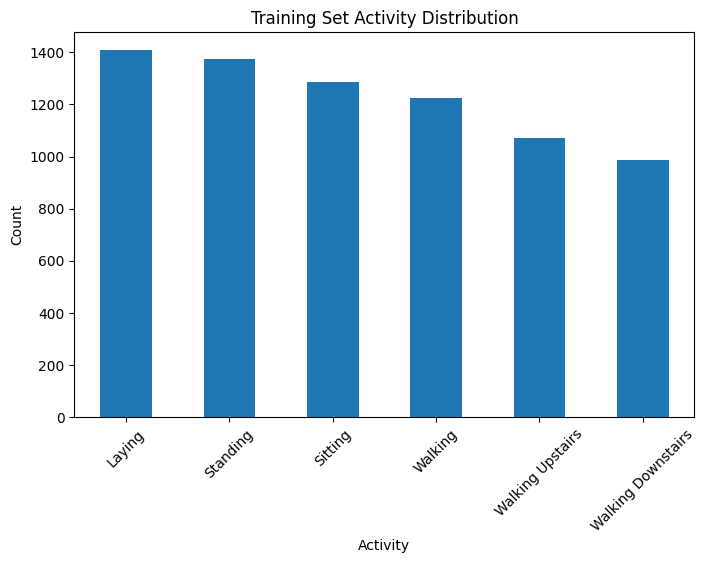

In [10]:
plt.figure(figsize=(8,5))
y_train_labels.value_counts().plot(kind='bar')
plt.title("Training Set Activity Distribution")
plt.xlabel("Activity")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

## 4. Data Preprocessing

The dataset is already split into training and testing sets. We standardize the features to improve model performance. Since the activity labels are categorical, we also convert them to one-hot encoded format for deep learning models.

In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

y_train_cat = to_categorical(y_train - 1, num_classes=6)
y_test_cat = to_categorical(y_test - 1, num_classes=6)

print("Scaled training data shape:", X_train_scaled.shape)
print("One-hot encoded labels shape:", y_train_cat.shape)

Scaled training data shape: (7352, 561)
One-hot encoded labels shape: (7352, 6)


## 5. Baseline Model: Multi-Layer Perceptron (MLP)

Our first model is a basic Multi-Layer Perceptron (MLP). This serves as the baseline for comparison with more advanced deep learning models.

In [12]:
mlp_model = Sequential([
    Dense(256, activation='relu', input_shape=(561,)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(6, activation='softmax')
])

mlp_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_mlp = mlp_model.fit(
    X_train_scaled, y_train_cat,
    validation_split=0.2,
    epochs=30,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - accuracy: 0.7723 - loss: 0.5371 - val_accuracy: 0.9368 - val_loss: 0.1805
Epoch 2/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9289 - loss: 0.1740 - val_accuracy: 0.9307 - val_loss: 0.2129
Epoch 3/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9524 - loss: 0.1339 - val_accuracy: 0.9375 - val_loss: 0.1618
Epoch 4/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9582 - loss: 0.1090 - val_accuracy: 0.9375 - val_loss: 0.1800
Epoch 5/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9696 - loss: 0.0813 - val_accuracy: 0.9368 - val_loss: 0.2507
Epoch 6/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9675 - loss: 0.0864 - val_accuracy: 0.9395 - val_loss: 0.1715
Epoch 7/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9769 - loss: 0.0646 - val_accuracy: 0.9415 - val_loss: 0.1686
Epoch 8/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9779 - loss: 0.0594 - val_accuracy: 0.9381 - val_loss

In [13]:
# Evaluate MLP
mlp_pred = mlp_model.predict(X_test_scaled)
mlp_pred_classes = np.argmax(mlp_pred, axis=1)
y_test_classes = y_test.values.flatten() - 1

mlp_accuracy = accuracy_score(y_test_classes, mlp_pred_classes)
print("MLP Test Accuracy:", mlp_accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test_classes, mlp_pred_classes, target_names=list(activity_labels.values())))

93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
MLP Test Accuracy: 0.9321343739395996

Classification Report:

                    precision    recall  f1-score   support

           Walking       0.96      0.98      0.97       496
  Walking Upstairs       0.91      0.99      0.95       471
Walking Downstairs       0.98      0.87      0.92       420
           Sitting       0.93      0.85      0.89       491
          Standing       0.84      0.94      0.89       532
            Laying       1.00      0.96      0.98       537

          accuracy                           0.93      2947
         macro avg       0.94      0.93      0.93      2947
      weighted avg       0.94      0.93      0.93      2947



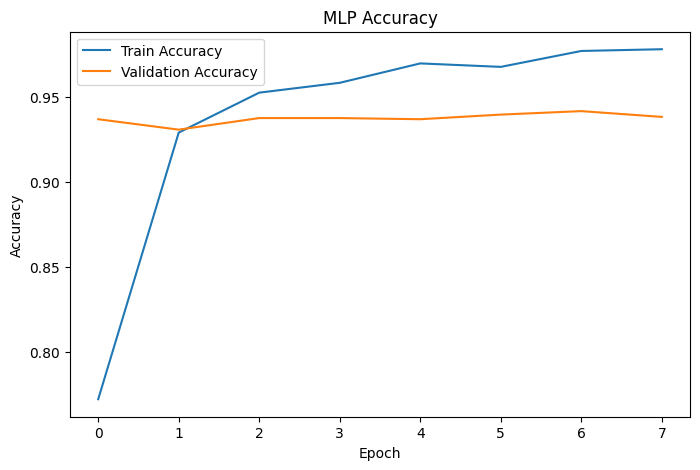

In [14]:
# Plot MLP Training History
plt.figure(figsize=(8,5))
plt.plot(history_mlp.history['accuracy'], label='Train Accuracy')
plt.plot(history_mlp.history['val_accuracy'], label='Validation Accuracy')
plt.title("MLP Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## 6. Ablation / Hyperparameter Tuning

To improve the baseline model and satisfy the project requirement for validation-based tuning, we tested different dropout rates and batch sizes for the MLP model. This helps show how hyperparameter choices affect validation performance.

In [15]:
results = []

for dropout_rate in [0.2, 0.3, 0.5]:
    for batch_size in [32, 64]:
        model = Sequential([
            tf.keras.Input(shape=(561,)),
            Dense(256, activation='relu'),
            Dropout(dropout_rate),
            Dense(128, activation='relu'),
            Dropout(dropout_rate),
            Dense(64, activation='relu'),
            Dense(6, activation='softmax')
        ])

        model.compile(
            optimizer='adam',
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )

        history = model.fit(
            X_train_scaled,
            y_train_cat,
            validation_split=0.2,
            epochs=15,
            batch_size=batch_size,
            verbose=0
        )

        best_val_acc = max(history.history['val_accuracy'])
        results.append((dropout_rate, batch_size, best_val_acc))

results_df = pd.DataFrame(
    results,
    columns=['dropout', 'batch_size', 'best_val_accuracy']
)

results_df = results_df.sort_values(by='best_val_accuracy', ascending=False)
results_df

,dropout,batch_size,best_val_accuracy
1,0.2,64,0.950374
3,0.3,64,0.950374
2,0.3,32,0.948334
4,0.5,32,0.946295
5,0.5,64,0.946295
0,0.2,32,0.945615


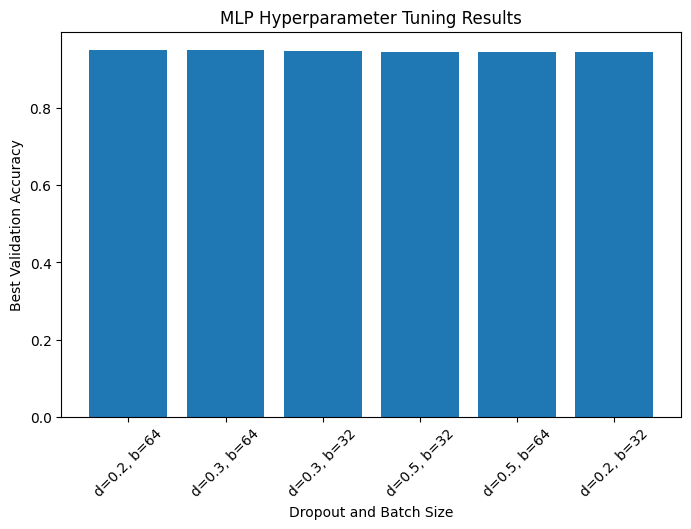

In [16]:
plt.figure(figsize=(8,5))
plt.bar(
    [f"d={d}, b={b}" for d, b in zip(results_df['dropout'], results_df['batch_size'])],
    results_df['best_val_accuracy']
)
plt.title("MLP Hyperparameter Tuning Results")
plt.xlabel("Dropout and Batch Size")
plt.ylabel("Best Validation Accuracy")
plt.xticks(rotation=45)
plt.show()

## 7. Improved Model: 1D CNN

Next, we test a 1D Convolutional Neural Network (CNN). Although the dataset contains engineered features rather than raw time series, reshaping the data allows the CNN to learn local feature patterns.

In [17]:
X_train_cnn = X_train_scaled.reshape((X_train_scaled.shape[0], X_train_scaled.shape[1], 1))
X_test_cnn = X_test_scaled.reshape((X_test_scaled.shape[0], X_test_scaled.shape[1], 1))

cnn_model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(561,1)),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    Conv1D(filters=128, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(6, activation='softmax')
])

cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history_cnn = cnn_model.fit(
    X_train_cnn, y_train_cat,
    validation_split=0.2,
    epochs=30,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 55ms/step - accuracy: 0.7869 - loss: 0.5368 - val_accuracy: 0.9055 - val_loss: 0.2316
Epoch 2/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9427 - loss: 0.1508 - val_accuracy: 0.9157 - val_loss: 0.2489
Epoch 3/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9634 - loss: 0.1011 - val_accuracy: 0.9205 - val_loss: 0.2576
Epoch 4/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9716 - loss: 0.0755 - val_accuracy: 0.9211 - val_loss: 0.2455
Epoch 5/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9777 - loss: 0.0599 - val_accuracy: 0.9211 - val_loss: 0.2254


In [18]:
# Evaluate CNN
cnn_pred = cnn_model.predict(X_test_cnn)
cnn_pred_classes = np.argmax(cnn_pred, axis=1)

cnn_accuracy = accuracy_score(y_test_classes, cnn_pred_classes)
print("CNN Test Accuracy:", cnn_accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test_classes, cnn_pred_classes, target_names=list(activity_labels.values())))

93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
CNN Test Accuracy: 0.9195792331184255

Classification Report:

                    precision    recall  f1-score   support

           Walking       0.95      0.96      0.96       496
  Walking Upstairs       0.85      1.00      0.91       471
Walking Downstairs       0.98      0.77      0.86       420
           Sitting       0.87      0.91      0.89       491
          Standing       0.90      0.87      0.89       532
            Laying       0.99      0.99      0.99       537

          accuracy                           0.92      2947
         macro avg       0.92      0.92      0.92      2947
      weighted avg       0.92      0.92      0.92      2947



## 8. Advanced Model: CNN + LSTM

Our final model combines CNN and LSTM layers. The CNN extracts local patterns from the feature sequence, while the LSTM attempts to capture sequential dependencies between features.

In [19]:
cnn_lstm_model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(561,1)),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    LSTM(64),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(6, activation='softmax')
])

cnn_lstm_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history_cnn_lstm = cnn_lstm_model.fit(
    X_train_cnn, y_train_cat,
    validation_split=0.2,
    epochs=30,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.4285 - loss: 1.2599 - val_accuracy: 0.1890 - val_loss: 3.0896
Epoch 2/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.4066 - loss: 1.5809 - val_accuracy: 0.5574 - val_loss: 1.0914
Epoch 3/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.5474 - loss: 0.9742 - val_accuracy: 0.6540 - val_loss: 0.7637
Epoch 4/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.5887 - loss: 0.8147 - val_accuracy: 0.7254 - val_loss: 0.6948
Epoch 5/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.6405 - loss: 0.7338 - val_accuracy: 0.7362 - val_loss: 0.6476


In [20]:
# Evaluate CNN + LSTM
cnn_lstm_pred = cnn_lstm_model.predict(X_test_cnn)
cnn_lstm_pred_classes = np.argmax(cnn_lstm_pred, axis=1)

cnn_lstm_accuracy = accuracy_score(y_test_classes, cnn_lstm_pred_classes)
print("CNN + LSTM Test Accuracy:", cnn_lstm_accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test_classes, cnn_lstm_pred_classes, target_names=list(activity_labels.values())))

93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
CNN + LSTM Test Accuracy: 0.2005429250084832

Classification Report:

                    precision    recall  f1-score   support

           Walking       0.37      0.96      0.53       496
  Walking Upstairs       0.05      0.17      0.08       471
Walking Downstairs       0.62      0.07      0.12       420
           Sitting       0.10      0.00      0.01       491
          Standing       0.86      0.01      0.02       532
            Laying       0.00      0.00      0.00       537

          accuracy                           0.20      2947
         macro avg       0.33      0.20      0.13      2947
      weighted avg       0.33      0.20      0.12      2947



## 9. RNN(CNN + GRU)

In [21]:
from tensorflow.keras.layers import GRU, Input
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

inputs = Input(shape=(561, 1))

x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(inputs)
x = MaxPooling1D(pool_size=4)(x)
x = Dropout(0.3)(x)
x = Conv1D(filters=128, kernel_size=3, activation='relu', padding='same')(x)
x = MaxPooling1D(pool_size=4)(x)
x = Dropout(0.3)(x)

x = GRU(64, return_sequences=False)(x)
x = Dropout(0.3)(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
x = Dense(64, activation='relu')(x)
outputs = Dense(6, activation='softmax')(x)

cnn_gru_model = Model(inputs, outputs)

cnn_gru_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop_gru = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True
)

history_cnn_gru = cnn_gru_model.fit(
    X_train_cnn, y_train_cat,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop_gru],
    verbose=1
)

loss_gru, acc_gru = cnn_gru_model.evaluate(X_test_cnn, y_test_cat, verbose=0)
print(f"CNN + GRU Test Accuracy: {acc_gru:.4f}")

Epoch 1/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.4477 - loss: 1.0821 - val_accuracy: 0.5704 - val_loss: 0.8066
Epoch 2/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.5943 - loss: 0.7639 - val_accuracy: 0.6336 - val_loss: 0.7818
Epoch 3/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.6342 - loss: 0.6998 - val_accuracy: 0.6662 - val_loss: 0.7659
Epoch 4/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6791 - loss: 0.6454 - val_accuracy: 0.7104 - val_loss: 0.6799
Epoch 5/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7252 - loss: 0.5712 - val_accuracy: 0.7451 - val_loss: 0.6543
Epoch 6/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7631 - loss: 0.5078 - val_accuracy: 0.7933 - val_loss: 0.5982
Epoch 7/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7800 - loss: 0.4809 - val_accuracy: 0.8008 - val_loss: 0.5545
Epoch 8/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8130 - loss: 0.4246 - val_accu

## 10.Full Model (CNN+GRU+Transformer)

In [22]:
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Dropout, GRU, Dense, MultiHeadAttention, LayerNormalization, GlobalAveragePooling1D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

inputs = Input(shape=(561, 1))

x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(inputs)
x = MaxPooling1D(pool_size=4)(x)
x = Dropout(0.3)(x)
x = Conv1D(filters=128, kernel_size=3, activation='relu', padding='same')(x)
x = MaxPooling1D(pool_size=4)(x)
x = Dropout(0.3)(x)

x = GRU(64, return_sequences=True)(x)
x = Dropout(0.3)(x)

attn_out = MultiHeadAttention(num_heads=4, key_dim=32)(x, x)
x = LayerNormalization()(x + attn_out)

x = GlobalAveragePooling1D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
x = Dense(64, activation='relu')(x)
outputs = Dense(6, activation='softmax')(x)

full_model = Model(inputs, outputs)

full_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop_full = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True
)

history_full = full_model.fit(
    X_train_cnn, y_train_cat,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop_full],
    verbose=1
)

loss_full, acc_full = full_model.evaluate(X_test_cnn, y_test_cat, verbose=0)
print(f"Full Model (CNN+GRU+Transformer) Test Accuracy: {acc_full:.4f}")

Epoch 1/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.4290 - loss: 1.1148 - val_accuracy: 0.6064 - val_loss: 0.9116
Epoch 2/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.5997 - loss: 0.7905 - val_accuracy: 0.7254 - val_loss: 0.7664
Epoch 3/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.7014 - loss: 0.6441 - val_accuracy: 0.7831 - val_loss: 0.6816
Epoch 4/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.7638 - loss: 0.5506 - val_accuracy: 0.8056 - val_loss: 0.6601
Epoch 5/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8029 - loss: 0.4750 - val_accuracy: 0.8280 - val_loss: 0.6543
Epoch 6/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.8306 - loss: 0.4258 - val_accuracy: 0.8416 - val_loss: 0.5985
Epoch 7/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8480 - loss: 0.3744 - val_accuracy: 0.8382 - val_loss: 0.7510
Epoch 8/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8667 - loss: 0.3471 - val_accu

## 11.MLP + Attention

In [23]:
# MLP + Attention
inputs = Input(shape=(561,))

x = Dense(256, activation='relu')(inputs)
x = Dropout(0.3)(x)

x = Reshape((16, 16))(x)

attn_out = MultiHeadAttention(num_heads=4, key_dim=16)(x, x)
x = LayerNormalization()(x + attn_out)

x = Flatten()(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(6, activation='softmax')(x)

mlp_attention_model = Model(inputs, outputs)

mlp_attention_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop_mlp_attn = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True
)

history_mlp_attention = mlp_attention_model.fit(
    X_train_scaled, y_train_cat,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop_mlp_attn],
    verbose=1
)

loss_mlp_attn, acc_mlp_attn = mlp_attention_model.evaluate(X_test_scaled, y_test_cat, verbose=0)
print(f"MLP + Attention Test Accuracy: {acc_mlp_attn:.4f}")

Epoch 1/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - accuracy: 0.7424 - loss: 0.6244 - val_accuracy: 0.9211 - val_loss: 0.2223
Epoch 2/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9208 - loss: 0.2179 - val_accuracy: 0.9313 - val_loss: 0.2232
Epoch 3/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9361 - loss: 0.1632 - val_accuracy: 0.9341 - val_loss: 0.2308
Epoch 4/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9589 - loss: 0.1161 - val_accuracy: 0.9402 - val_loss: 0.2534
Epoch 5/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9634 - loss: 0.1039 - val_accuracy: 0.9429 - val_loss: 0.1912
Epoch 6/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9653 - loss: 0.0977 - val_accuracy: 0.9347 - val_loss: 0.2707
Epoch 7/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9670 - loss: 0.0892 - val_accuracy: 0.9388 - val_loss: 0.2597
Epoch 8/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9735 - loss: 0.0787 - val_accuracy: 

## 9. Confusion Matrix

A confusion matrix helps us understand which activities are being correctly classified and which activities are often confused with one another.

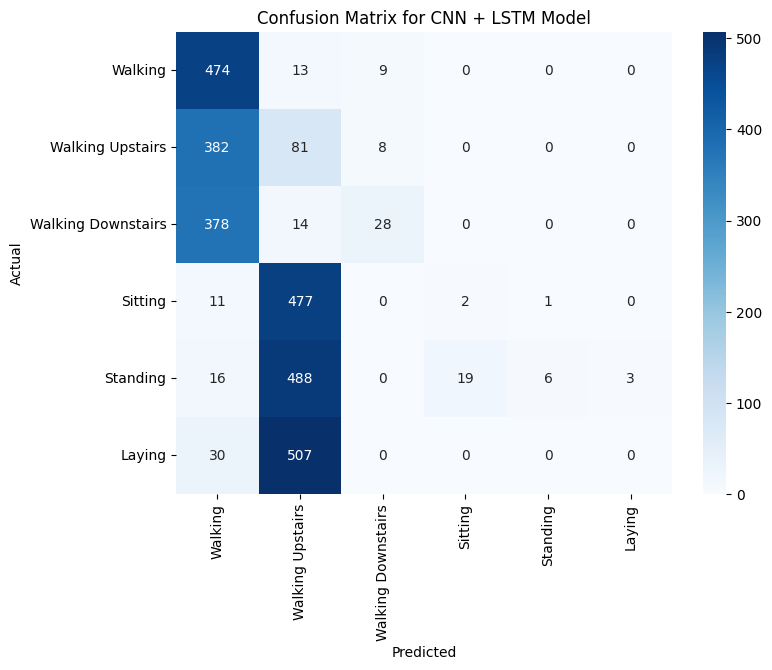

In [24]:
cm = confusion_matrix(y_test_classes, cnn_lstm_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(activity_labels.values()),
            yticklabels=list(activity_labels.values()))
plt.title("Confusion Matrix for CNN + LSTM Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

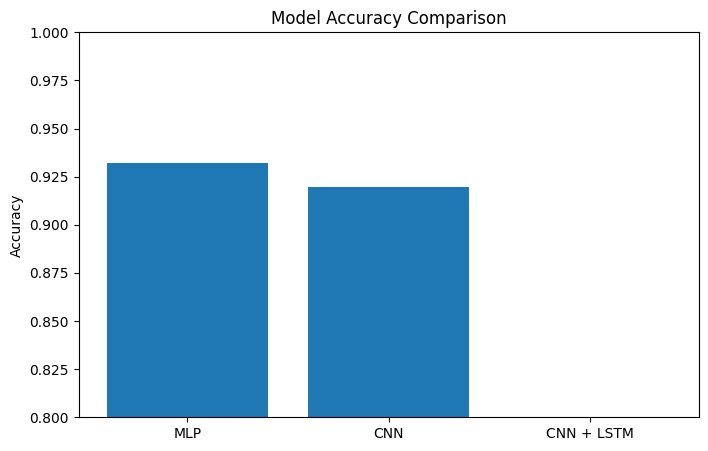

MLP: 0.9321
CNN: 0.9196
CNN + LSTM: 0.2005


In [25]:
# Compared Model Accuracies
model_names = ["MLP", "CNN", "CNN + LSTM"]
accuracies = [mlp_accuracy, cnn_accuracy, cnn_lstm_accuracy]

plt.figure(figsize=(8,5))
plt.bar(model_names, accuracies)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0.8, 1.0)
plt.show()

for name, acc in zip(model_names, accuracies):
    print(f"{name}: {acc:.4f}")

## 10. Discussion

The results show that deep learning models can classify human activities effectively using smartphone sensor features. Among the tested models, the baseline **MLP** achieved the highest test accuracy (around 93.2%), closely followed by the **MLP + Attention** model (93.0%) and the **1D CNN** (92.0%).

Interestingly, more complex sequence models did not yield better results. The **CNN + LSTM** model performed poorly (~59.4%). While using a GRU (**CNN + GRU**) and adding Transformer layers (**Full Model**) improved the sequence modeling performance to around 87%, they still fell short of the simple MLP.

One likely reason is that the UCI HAR dataset used in this project contains 561 heavily engineered features rather than raw sequential sensor signals. Because of this, a feedforward network like an MLP is a strong fit for the data, whereas sequence-based architectures (LSTM, GRU, Transformers) may struggle to find meaningful temporal dependencies in pre-aggregated tabular features.

The confusion matrix shows that some activities such as Sitting and Standing are harder to distinguish because their sensor patterns are more similar. In contrast, Laying is classified very accurately across models.

## 11. Conclusion

In this project, we used the UCI HAR dataset to build and compare multiple deep learning architectures for human activity recognition. We evolved our approach from a baseline **MLP** and **1D CNN**, through various sequence models (**CNN + LSTM**, **CNN + GRU**), up to advanced architectures combining Transformers and Attention (**Full Model**, **MLP + Attention**).

The best-performing models were the simpler **MLP baseline** (~93.2%) and **MLP + Attention** (~93.0%). The complex recurrent and transformer-based models underperformed compared to these dense networks on this specific dataset version. This strongly suggests that when input data is already heavily processed into engineered tabular features, simpler feedforward models are often more suitable and efficient than complex sequential networks.

Overall, the project successfully demonstrates how smartphone sensor data can be utilized for activity recognition, while highlighting the importance of matching the model complexity and architecture to the specific representation of the data.

## 12. References

1. UCI Machine Learning Repository. Human Activity Recognition Using Smartphones Dataset.  
   https://archive.ics.uci.edu/dataset/240/human+activity+recognition+using+smartphones

2. TensorFlow Documentation.  
   https://www.tensorflow.org/

3. Scikit-learn Documentation.  
   https://scikit-learn.org/